In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
# read the data into a pandas Dataframe object
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
gender = pd.read_csv('gender_submission.csv')

In [3]:
# to show the top5 rows of Datasets
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# to show number of rows and columns of csv file
train.shape

(891, 12)

In [5]:
# to show the top5 rows of Datasets
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [6]:
# to show number of rows and columns of csv file
test.shape

(418, 11)

In [7]:
# to show the top5 rows of Datasets
gender.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [8]:
# to show number of rows and columns of csv file
gender.shape

(418, 2)

In [9]:
# concat method is used to join gender and test DataFrame
df = pd.concat([gender, test], axis = 1)
# T.drop_duplicates() is used to drop the duplicate columns
# storing the values in df1
df1 = df.T.drop_duplicates().T
df1.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [10]:
# concat method is used to join train and df1 DataFrame and storing the value in df2
df2 = pd.concat([train, df1], axis = 0)
df2 = df2.reset_index(drop = True)
df2.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S


In [11]:
# to show the last 5 rows of Datasets
df2.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1304,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.05,NaN,S
1305,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9,C105,C
1306,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.25,NaN,S
1307,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.05,NaN,S
1308,1309,0,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [12]:
# to show number of rows and columns of csv file
df2.shape

(1309, 12)

In [13]:
# to show the information of above Datasets
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   PassengerId  1309 non-null   object
 1   Survived     1309 non-null   object
 2   Pclass       1309 non-null   object
 3   Name         1309 non-null   object
 4   Sex          1309 non-null   object
 5   Age          1046 non-null   object
 6   SibSp        1309 non-null   object
 7   Parch        1309 non-null   object
 8   Ticket       1309 non-null   object
 9   Fare         1308 non-null   object
 10  Cabin        295 non-null    object
 11  Embarked     1307 non-null   object
dtypes: object(12)
memory usage: 122.8+ KB


In [14]:
#convert object datatype into float and integer
df2["PassengerId"] = df2["PassengerId"].astype(int)
df2["Survived"] = df2["Survived"].astype(int)
df2["Pclass"] = df2["Pclass"].astype(int)
df2["Age"] = df2["Age"].astype(float)
df2["SibSp"] = df2["SibSp"].astype(int)
df2["Parch"] = df2["Parch"].astype(int)
df2["Fare"] = df2["Fare"].astype(float)

In [15]:
# to show the datatype
print(df2.PassengerId.dtype)
print(df2.Survived.dtype)
print(df2.Pclass.dtype)
print(df2.Age.dtype)
print(df2.SibSp.dtype)
print(df2.Parch.dtype)
print(df2.Fare.dtype)

int32
int32
int32
float64
int32
int32
float64


In [16]:
# to show the sum of null value in each column
df2.isnull().sum()

PassengerId       0
Survived          0
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

In [17]:
# drop or delete the column
df2 = df2.drop(columns = ['Cabin'], axis = 1)

In [18]:
# fill missing values using mean of the numerical column
df2['Age'] = df2['Age'].fillna(df['Age'].mean())
df2['Fare'] = df2['Fare'].fillna(df['Fare'].mean())

In [19]:
# fill missing values using mode of that categorical column
df2['Embarked'] = df2['Embarked'].fillna(df['Embarked'].mode()[0])

In [20]:
# used describe() for object datatype
df2.describe(include='object')

,Name,Sex,Ticket,Embarked
count,1309,1309,1309,1309
unique,1307,2,929,3
top,"Connolly, Miss. Kate",male,CA. 2343,S
freq,2,843,11,916


In [21]:
# to show statistical value of numerical column
df2.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000
mean,655.000000,0.377387,2.294882,29.959787,0.498854,0.385027,33.297261
std,378.020061,0.484918,0.837836,12.884149,1.041658,0.865560,51.738919
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,22.000000,0.000000,0.000000,7.895800
50%,655.000000,0.000000,3.000000,30.272590,0.000000,0.000000,14.454200
75%,982.000000,1.000000,3.000000,35.000000,1.000000,0.000000,31.275000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


In [22]:
# to show the all column name
df2.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

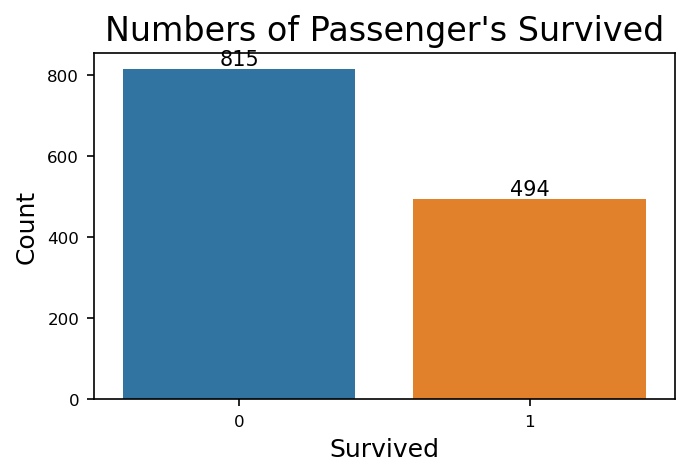

In [23]:
plt.figure(figsize = (5,3), dpi = 150)
ax = sns.countplot(x = 'Survived', data = df2)
for bars in ax.containers:
    ax.bar_label(bars)

ax.set_xlabel('Survived', size = 12)    
ax.set_ylabel('Count', size = 12)
plt.xticks(fontsize = 8)
plt.yticks(fontsize = 8)
plt.title("Numbers of Passenger's Survived", size = 16)
plt.show()

<b> 815 Passenger's died and 494 survived in Titanic Disaster

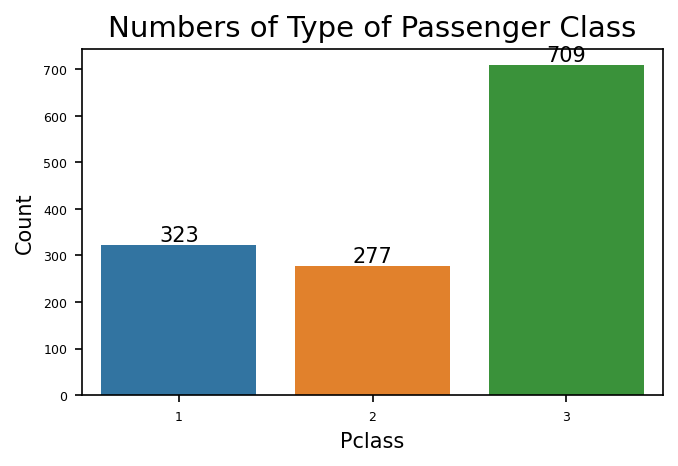

In [24]:
plt.figure(figsize = (5,3), dpi = 150)
ax = sns.countplot(x = 'Pclass', data = df2)
for bars in ax.containers:
    ax.bar_label(bars)

ax.set_xlabel('Pclass', size = 10)    
ax.set_ylabel('Count', size = 10)
plt.xticks(fontsize = 6)
plt.yticks(fontsize = 6)
plt.title("Numbers of Type of Passenger Class", size = 14)
plt.show()

<b> In Titanic disaster, Passenger of 1st class of Pclass is 323, Passengers of 2nd class of Pclass is 277 and Passenger of 3rd class of Pclass is 709 which is highest

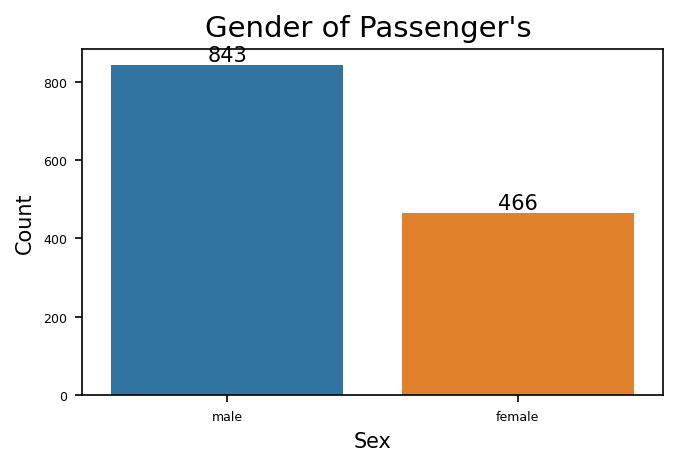

In [25]:
plt.figure(figsize = (5,3), dpi = 150)
ax = sns.countplot(x = 'Sex', data = df2)
for bars in ax.containers:
    ax.bar_label(bars)

ax.set_xlabel('Sex', size = 10)    
ax.set_ylabel('Count', size = 10)
plt.xticks(fontsize = 6)
plt.yticks(fontsize = 6)
plt.title("Gender of Passenger's ", size = 14)
plt.show()

<b> 843 was Male and 466 was Female. Male is more than Female

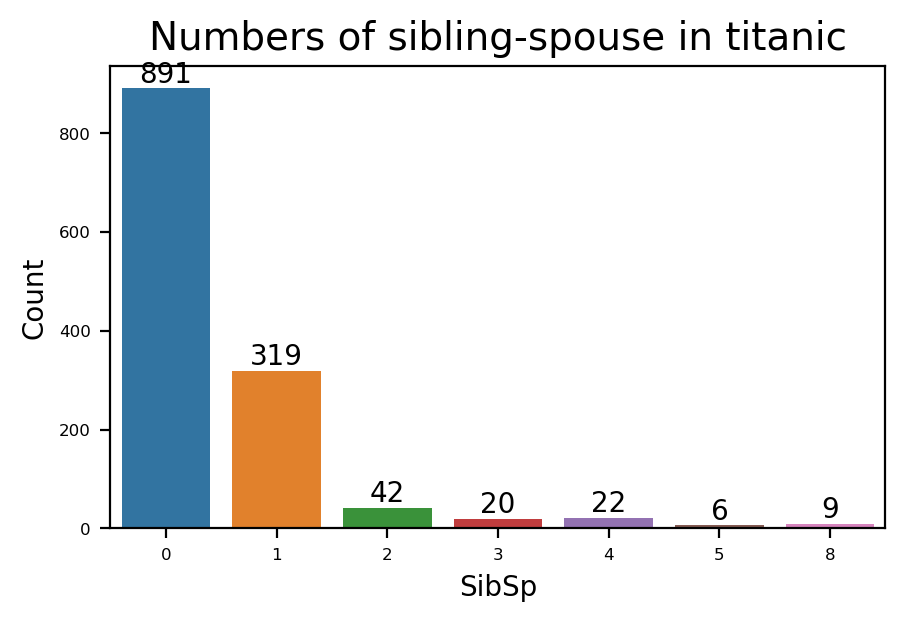

In [26]:
plt.figure(figsize = (5,3), dpi = 200)
ax = sns.countplot(x = 'SibSp', data = df2)
for bars in ax.containers:
    ax.bar_label(bars)

ax.set_xlabel('SibSp', size = 10)    
ax.set_ylabel('Count', size = 10)
plt.xticks(fontsize = 6)
plt.yticks(fontsize = 6)
plt.title("Numbers of sibling-spouse in titanic", size = 14)
plt.show()

<b> Most of Passengers alone travel in Titanic which is 891

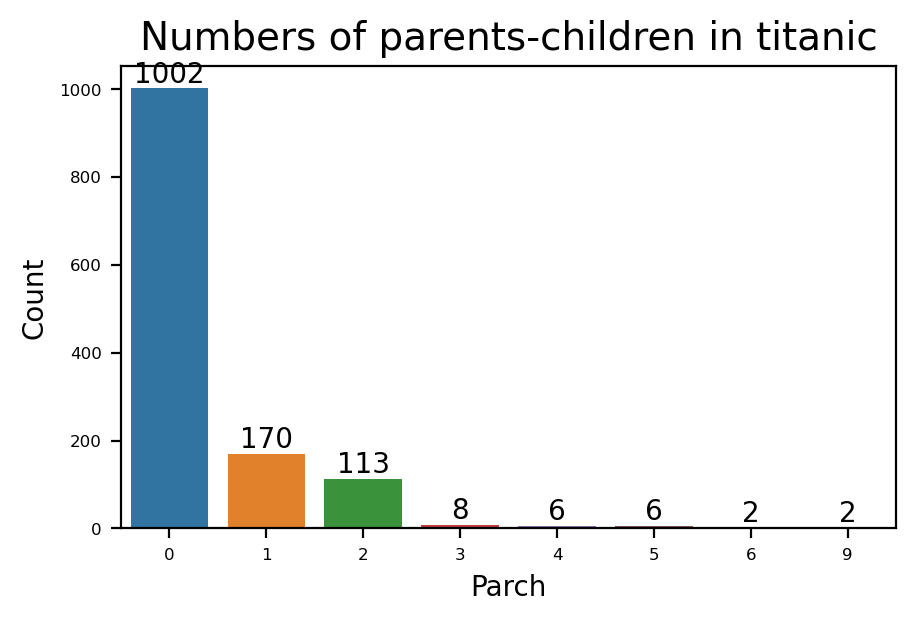

In [27]:
plt.figure(figsize = (5,3), dpi = 200)
ax = sns.countplot(x = 'Parch', data = df2)
for bars in ax.containers:
    ax.bar_label(bars)

ax.set_xlabel('Parch', size = 10)    
ax.set_ylabel('Count', size = 10)
plt.xticks(fontsize = 6)
plt.yticks(fontsize = 6)
plt.title("Numbers of parents-children in titanic", size = 14)
plt.show()

<b> 1002 Passenger alone travel in Titanic, 170 Passenger travel with 1 parent-children, 113 Passenger travel with 2 parent-children

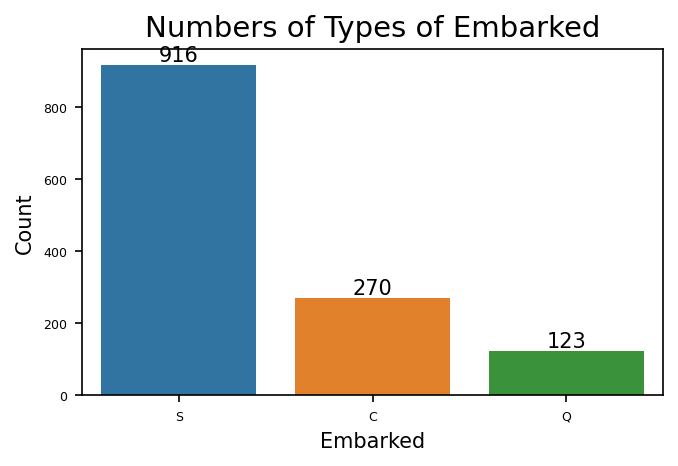

In [28]:
plt.figure(figsize = (5,3), dpi = 150)
ax = sns.countplot(x = 'Embarked', data = df2)
for bars in ax.containers:
    ax.bar_label(bars)

ax.set_xlabel('Embarked', size = 10)    
ax.set_ylabel('Count', size = 10)
plt.xticks(fontsize = 6)
plt.yticks(fontsize = 6)
plt.title("Numbers of Types of Embarked", size = 14)
plt.show()

<b> 916 Passengers had come from 'S' city, 270 Passengers had come from 'C' city and 123 Passengers had come from 'Q' city

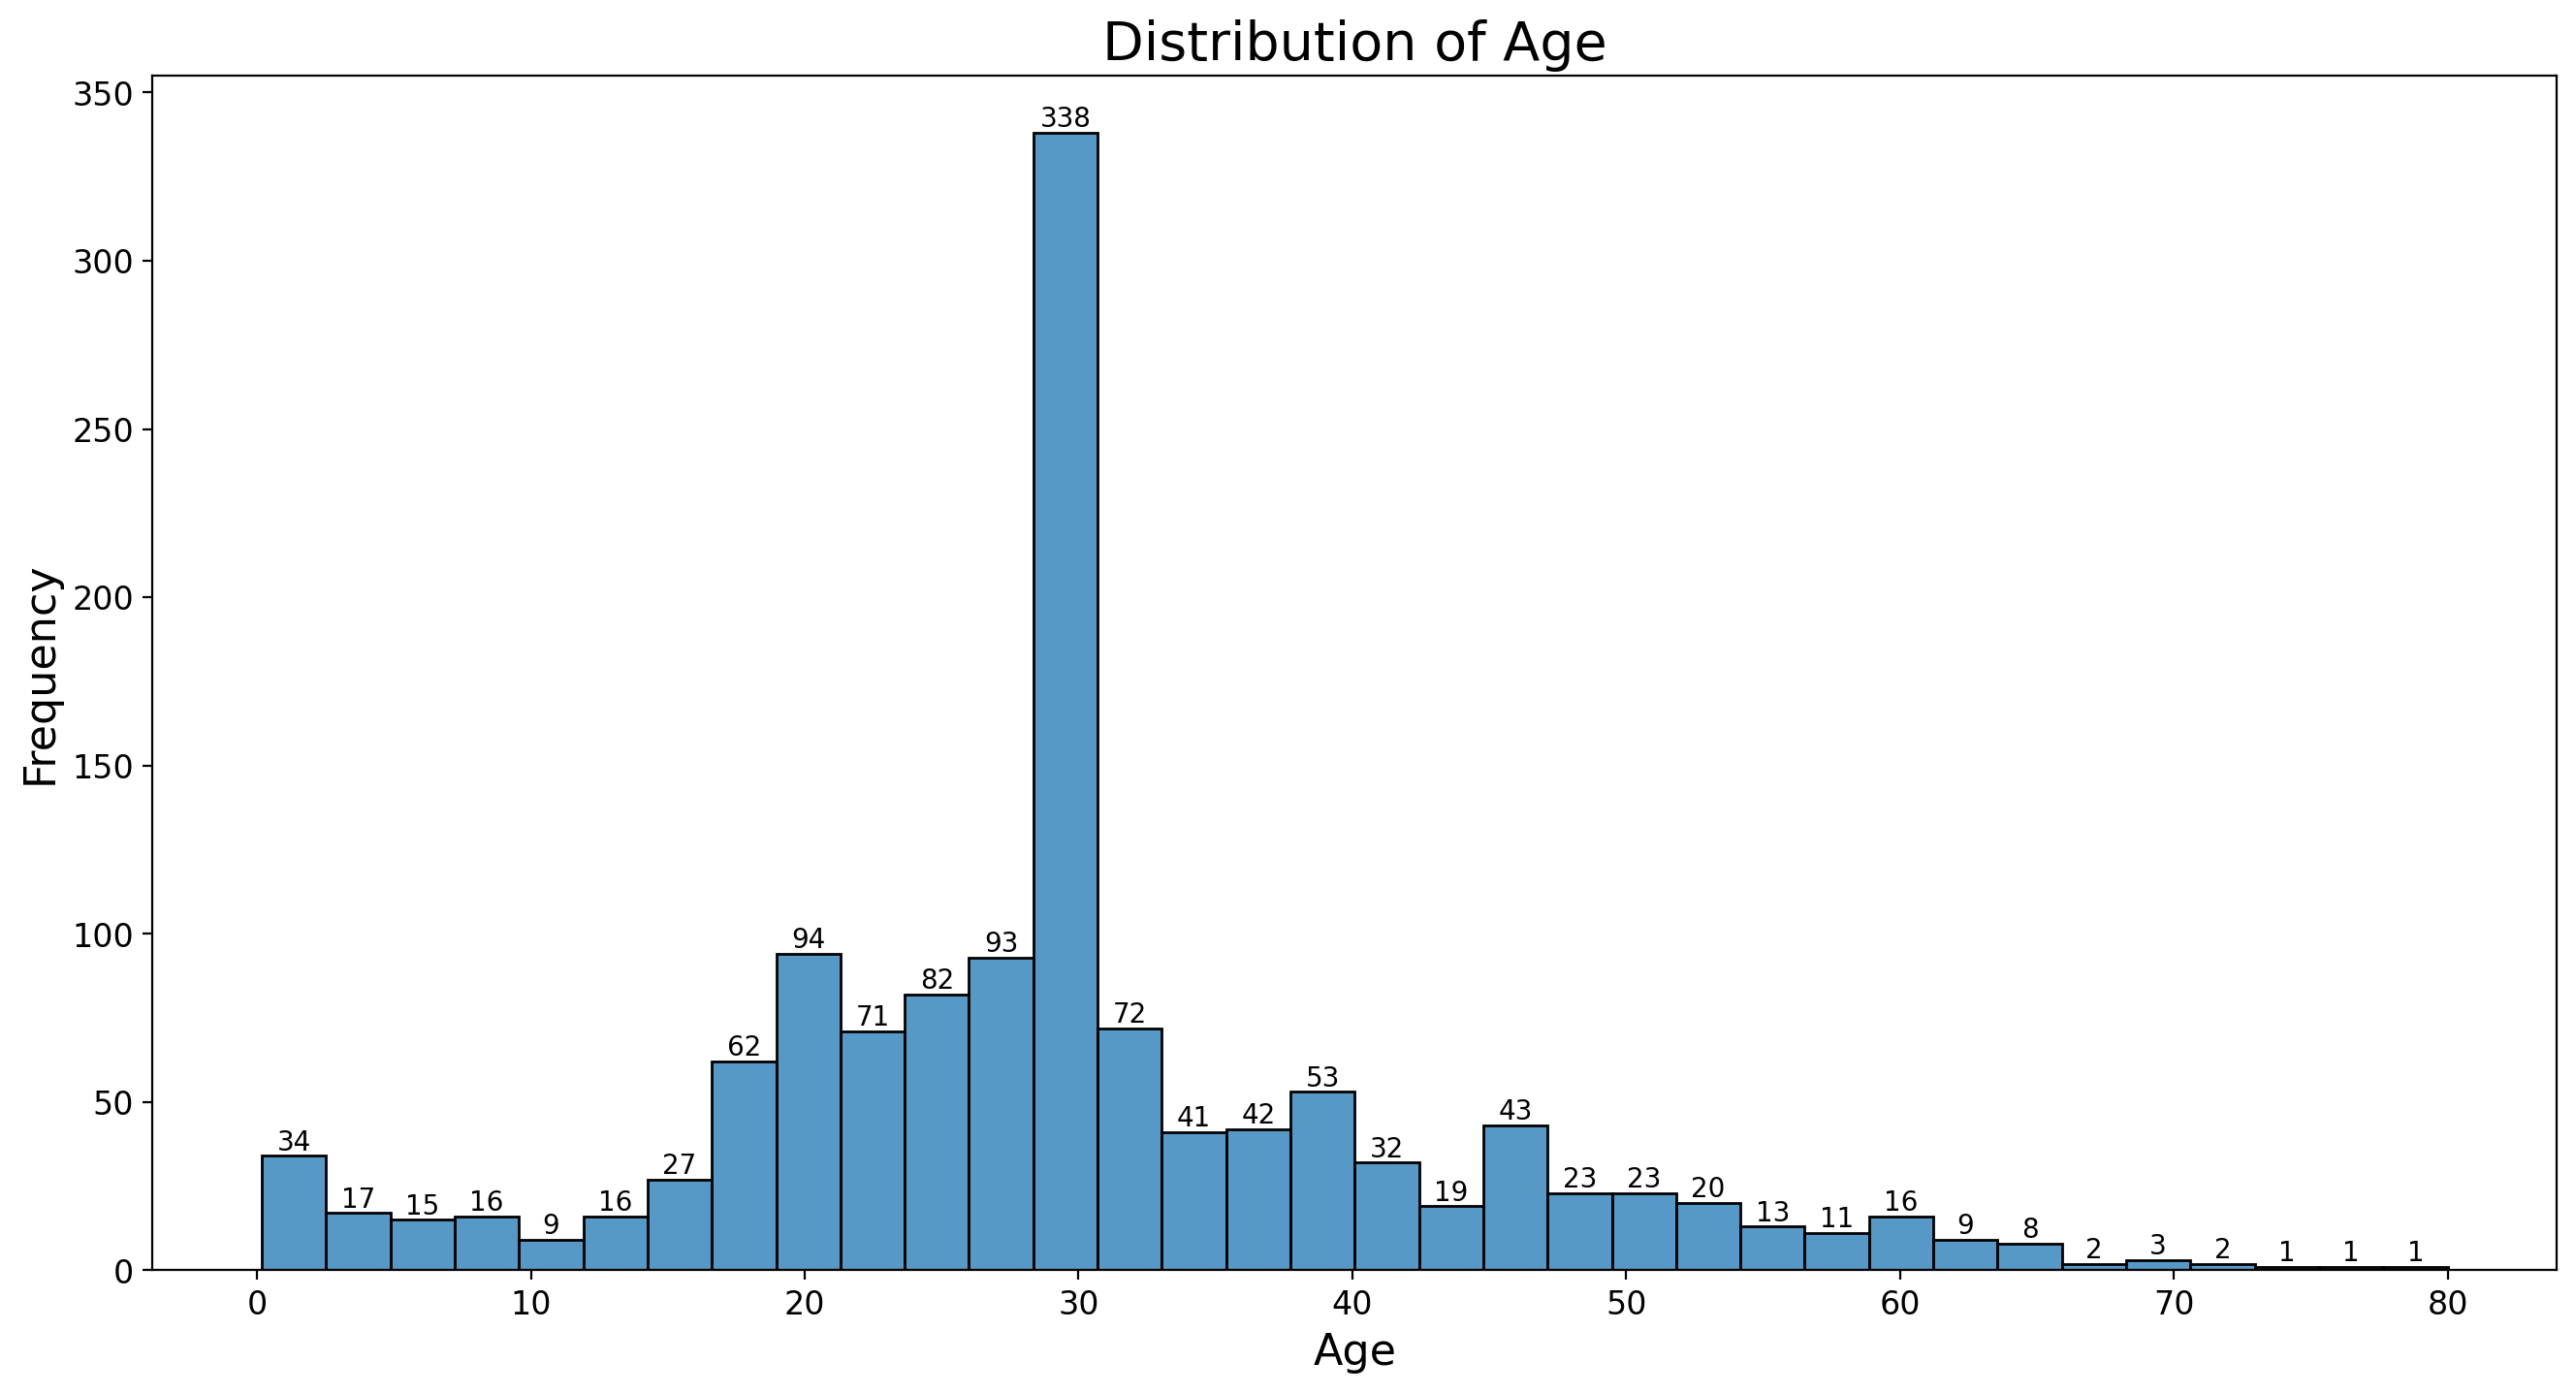

In [29]:
plt.figure(figsize = (16,8), dpi = 200)
ax = sns.histplot(df2['Age'])
for bars in ax.containers:
    ax.bar_label(bars)

ax.set_xlabel('Age', size = 16)    
ax.set_ylabel('Frequency', size = 16)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.title("Distribution of Age", size = 20)
plt.show()

<b> Most of the Passenger's went on Titanic, 30 age group.

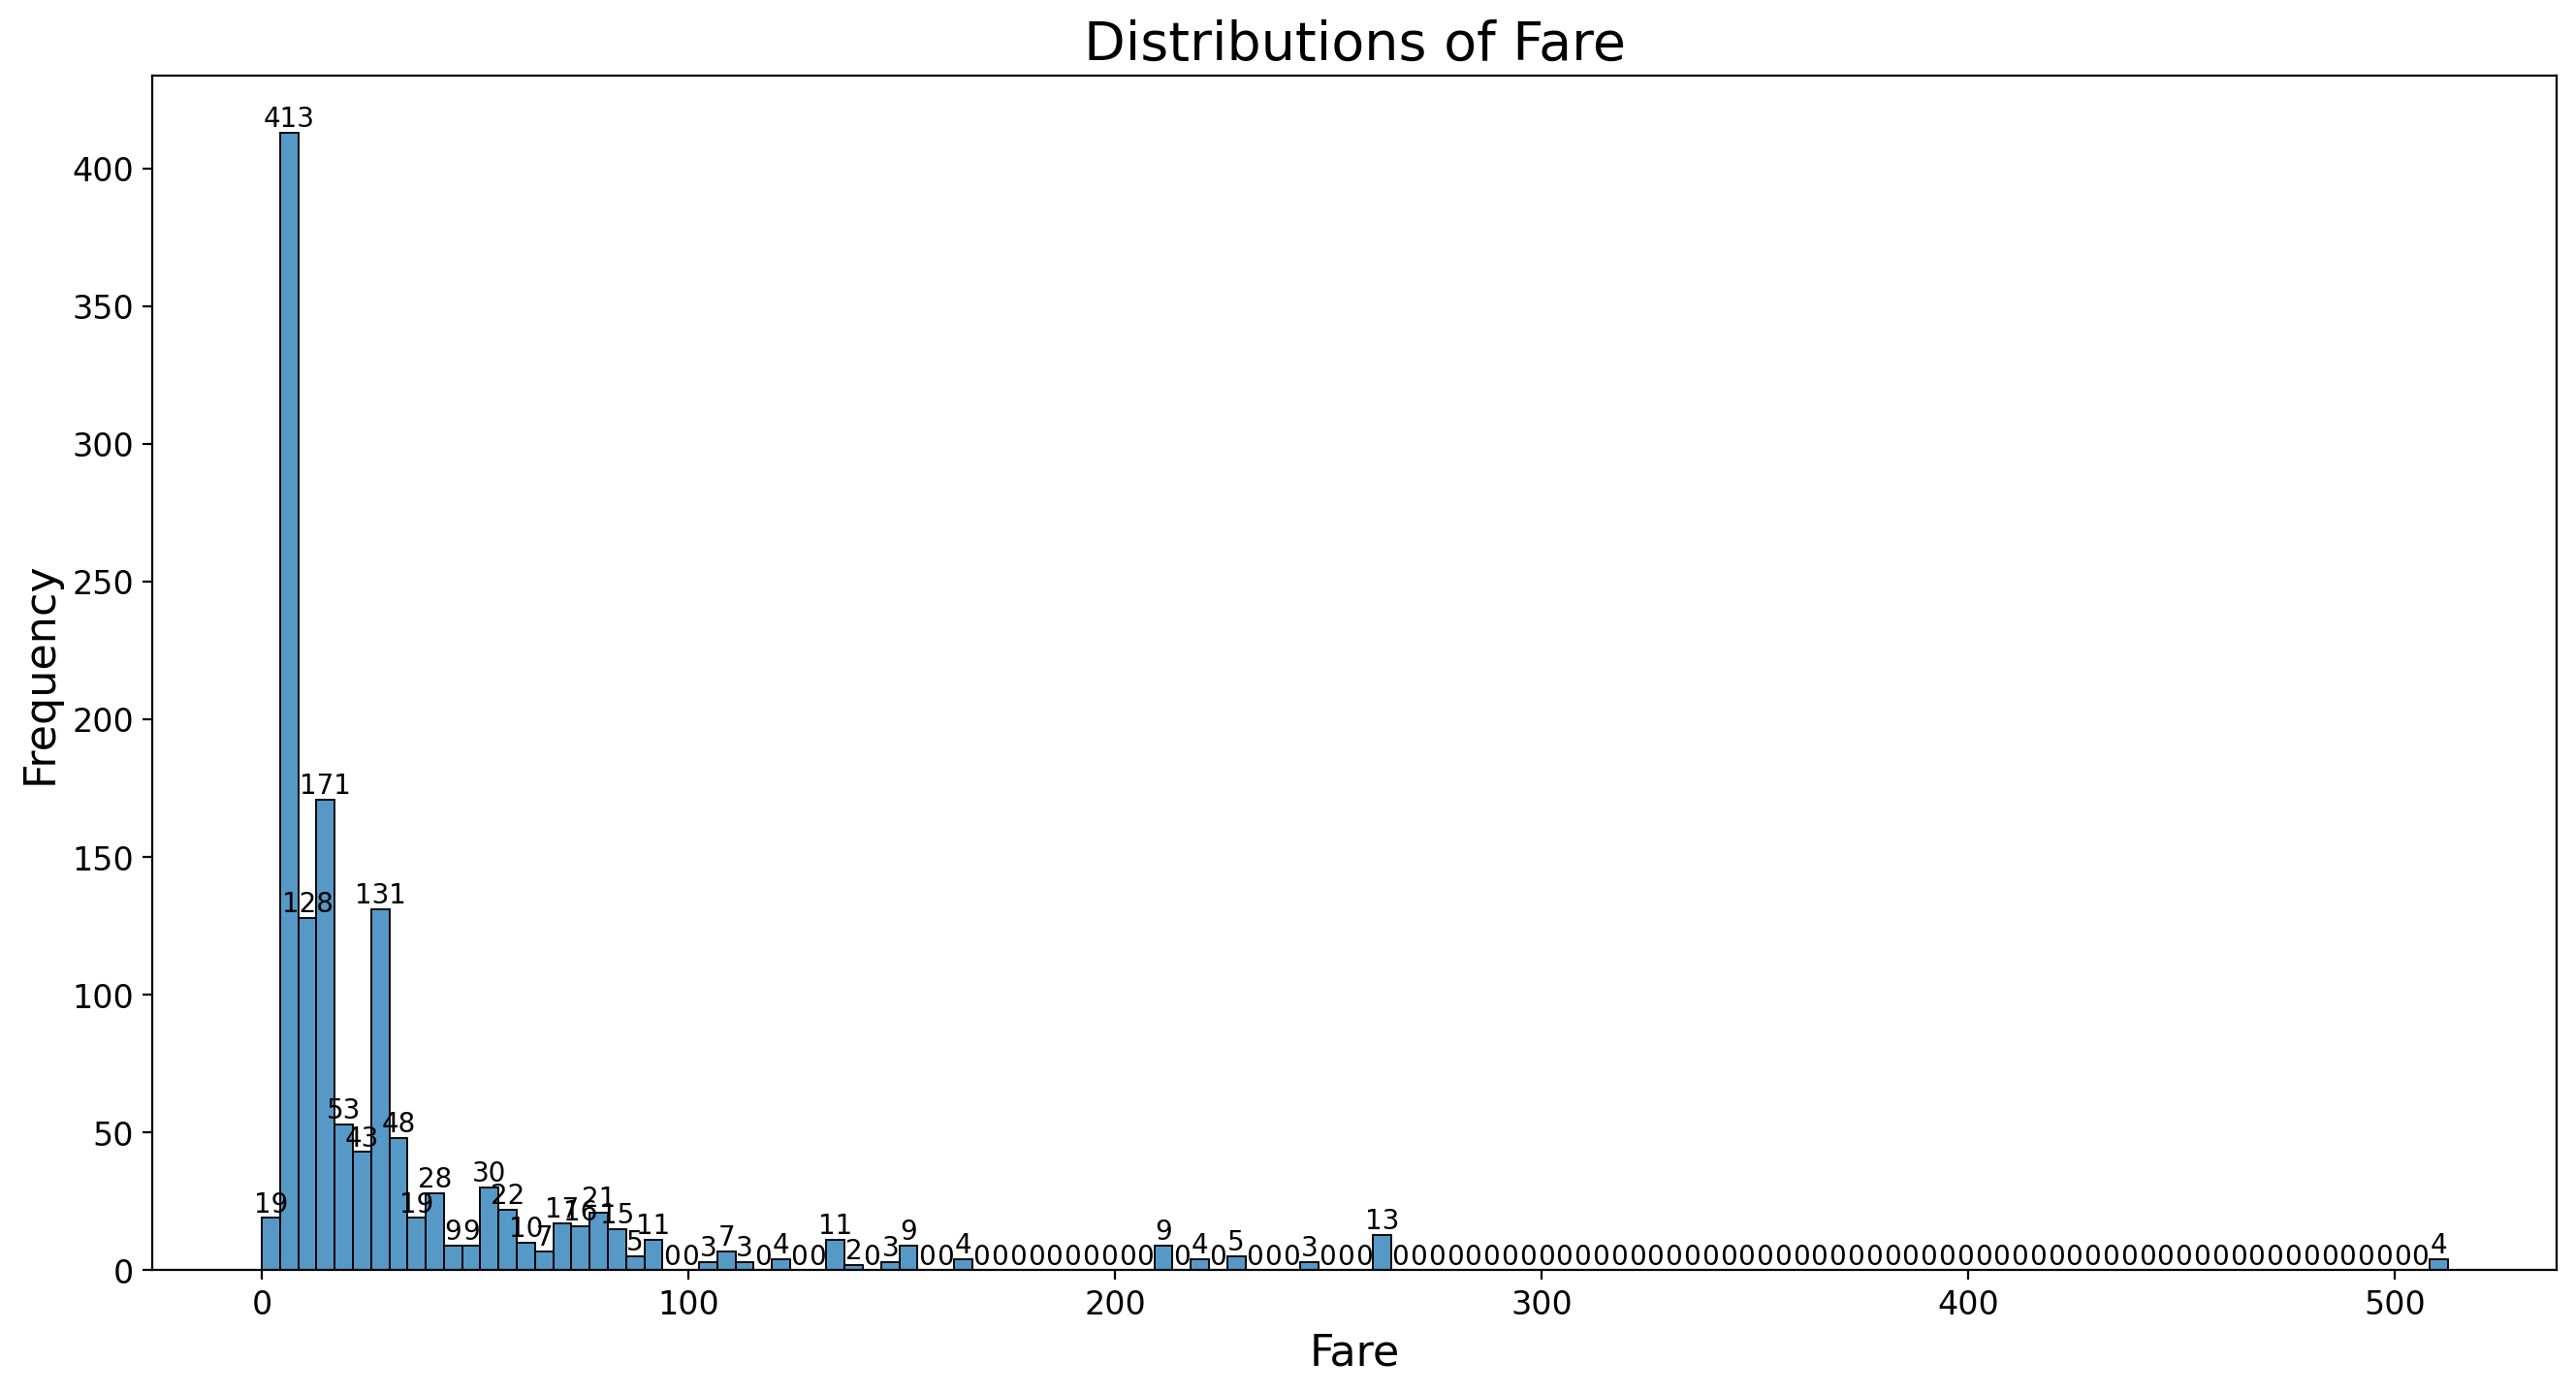

In [30]:
plt.figure(figsize = (16,8), dpi = 200)
ax = sns.histplot(df2['Fare'])
for bars in ax.containers:
    ax.bar_label(bars)

ax.set_xlabel('Fare', size = 16)    
ax.set_ylabel('Frequency', size = 16)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.title("Distributions of Fare", size = 20)
plt.show()

In [31]:
print(df2['Fare'].skew())
print(df2['Fare'].kurt())

4.369261051502992
27.05016932976346


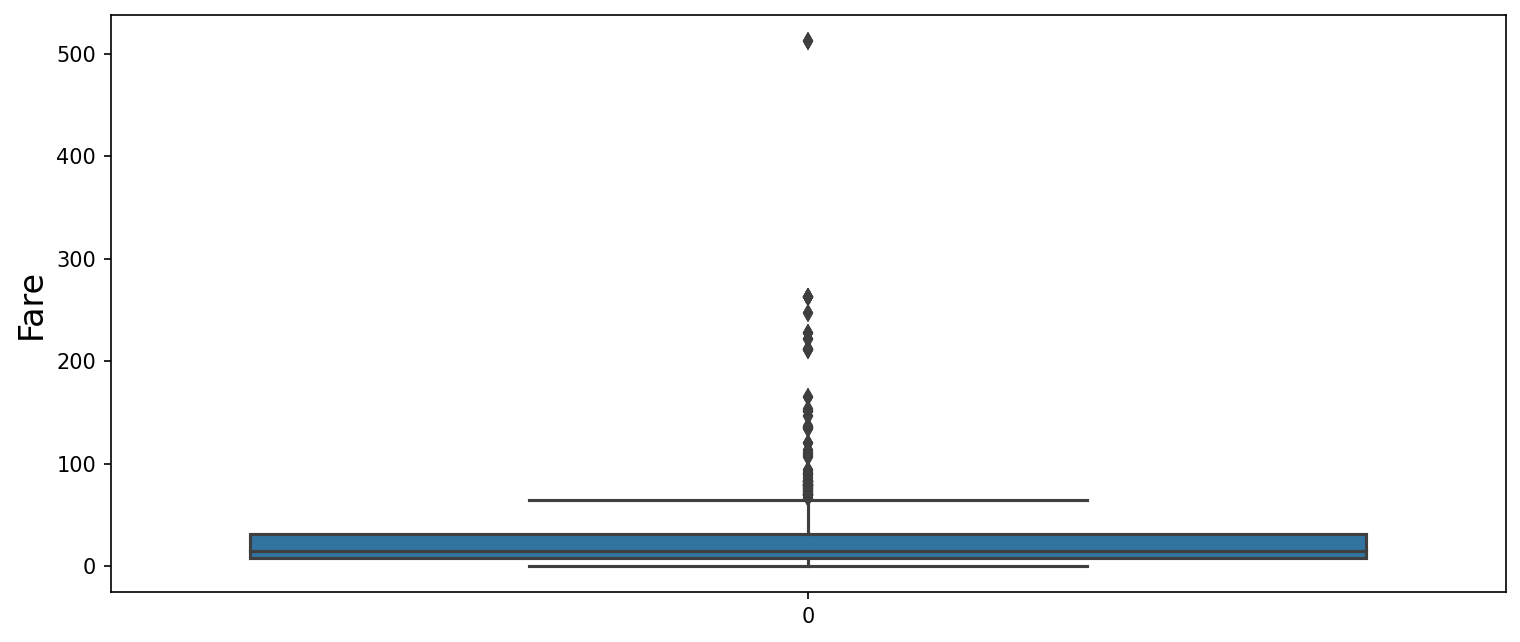

In [32]:
plt.figure(figsize = (12,5), dpi = 150)
ax = sns.boxplot(df2['Fare'])
for bars in ax.containers:
    ax.bar_label(bars)
    
ax.set_ylabel('Fare', size = 16)
plt.show()

<b> Highly skewed data, a lot of people had cheaper tickets and there are lot of outliers

<Figure size 2400x1000 with 0 Axes>

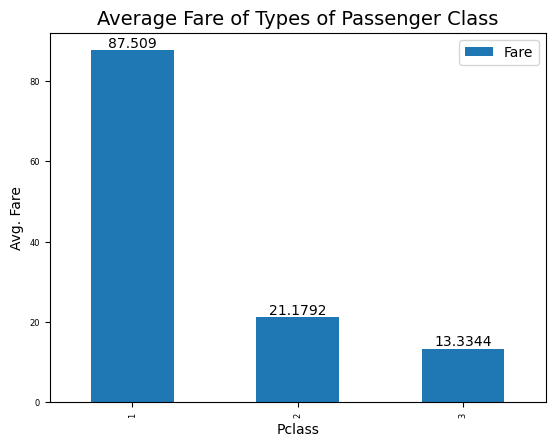

In [33]:
x = df2.pivot_table(index = 'Pclass', values = 'Fare')
plt.figure(figsize = (12,5), dpi = 200)
ax = x.plot(kind = 'bar')
for bars in ax.containers:
    ax.bar_label(bars)

ax.set_xlabel('Pclass', size = 10)    
ax.set_ylabel('Avg. Fare', size = 10)
plt.xticks(fontsize = 6)
plt.yticks(fontsize = 6)
plt.title("Average Fare of Types of Passenger Class", size = 14)
plt.show()

<b> According to Passenger's class, Average Fare of 1st class is highest beacause Ticket Fare is High

<Figure size 2400x1000 with 0 Axes>

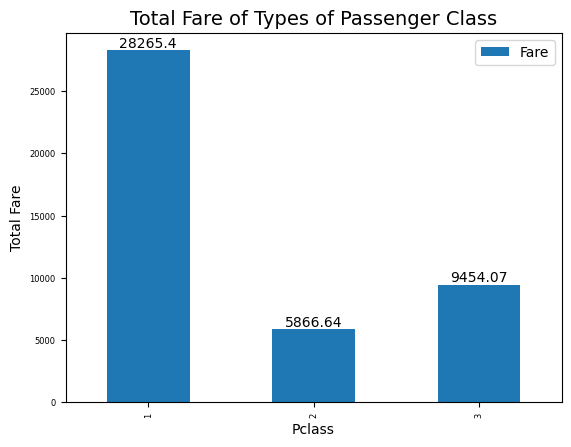

In [34]:
x = df2.pivot_table(index = 'Pclass', values = 'Fare', aggfunc = np.sum)
plt.figure(figsize = (12,5), dpi = 200)
ax = x.plot(kind = 'bar')
for bars in ax.containers:
    ax.bar_label(bars)

ax.set_xlabel('Pclass', size = 10)    
ax.set_ylabel('Total Fare', size = 10)
plt.xticks(fontsize = 6)
plt.yticks(fontsize = 6)
plt.title("Total Fare of Types of Passenger Class", size = 14)
plt.show()

<b> According to Passenger's class, 3rd class of Total Ticket Fare is 2nd highest beacause Passenger's is more and Ticket Fare is low

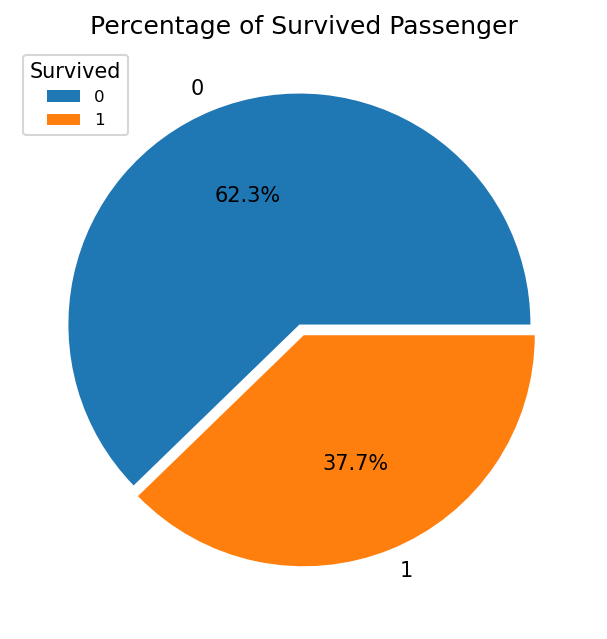

In [35]:
x = df2.groupby(['Survived'])['PassengerId'].count()
labels = [0,1]
explode=(0.05,0)
plt.figure(figsize = (12,5), dpi = 150)
plt.pie(x, labels = labels, autopct='%0.1f%%',explode = explode, labeldistance = 1.1, textprops = {'fontsize' : 10})
plt.legend(labels,title = 'Survived', loc = 2, fontsize = 8)
plt.title('Percentage of Survived Passenger', size = 12)
plt.show()

<b> 37.7% People are survived in Titanic disaster

<Figure size 2400x1000 with 0 Axes>

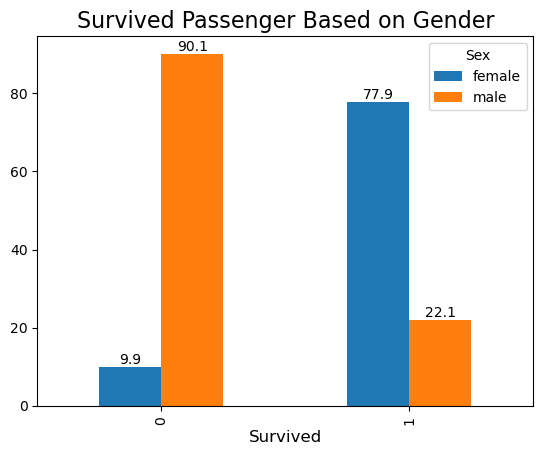

In [36]:
x = pd.crosstab(df2['Survived'],df2['Sex']).apply(lambda r : round((r/r.sum())*100,1),axis = 1)

plt.figure(figsize = (12,5), dpi = 200)
ax = x.plot(kind = 'bar')
for bars in ax.containers:
    ax.bar_label(bars)
    
ax.set_xlabel('Survived', size = 12)    
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
plt.title("Survived Passenger Based on Gender", size = 16)
plt.show()

<b> Female are more Survived than Male which is 77.9%

<Figure size 2400x1000 with 0 Axes>

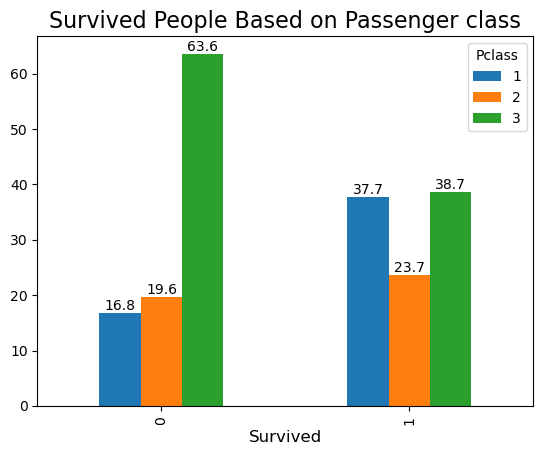

In [37]:
y = pd.crosstab(df2['Survived'],df2['Pclass']).apply(lambda r : round((r/r.sum())*100,1),axis = 1)
plt.figure(figsize = (12,5), dpi = 200)
ax = y.plot(kind = 'bar')
for bars in ax.containers:
    ax.bar_label(bars)
    
ax.set_xlabel('Survived', size = 12)    
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
plt.title("Survived People Based on Passenger class", size = 16)
plt.show()    


<b> Most of the Passengers died in 3 class which is 63.6%

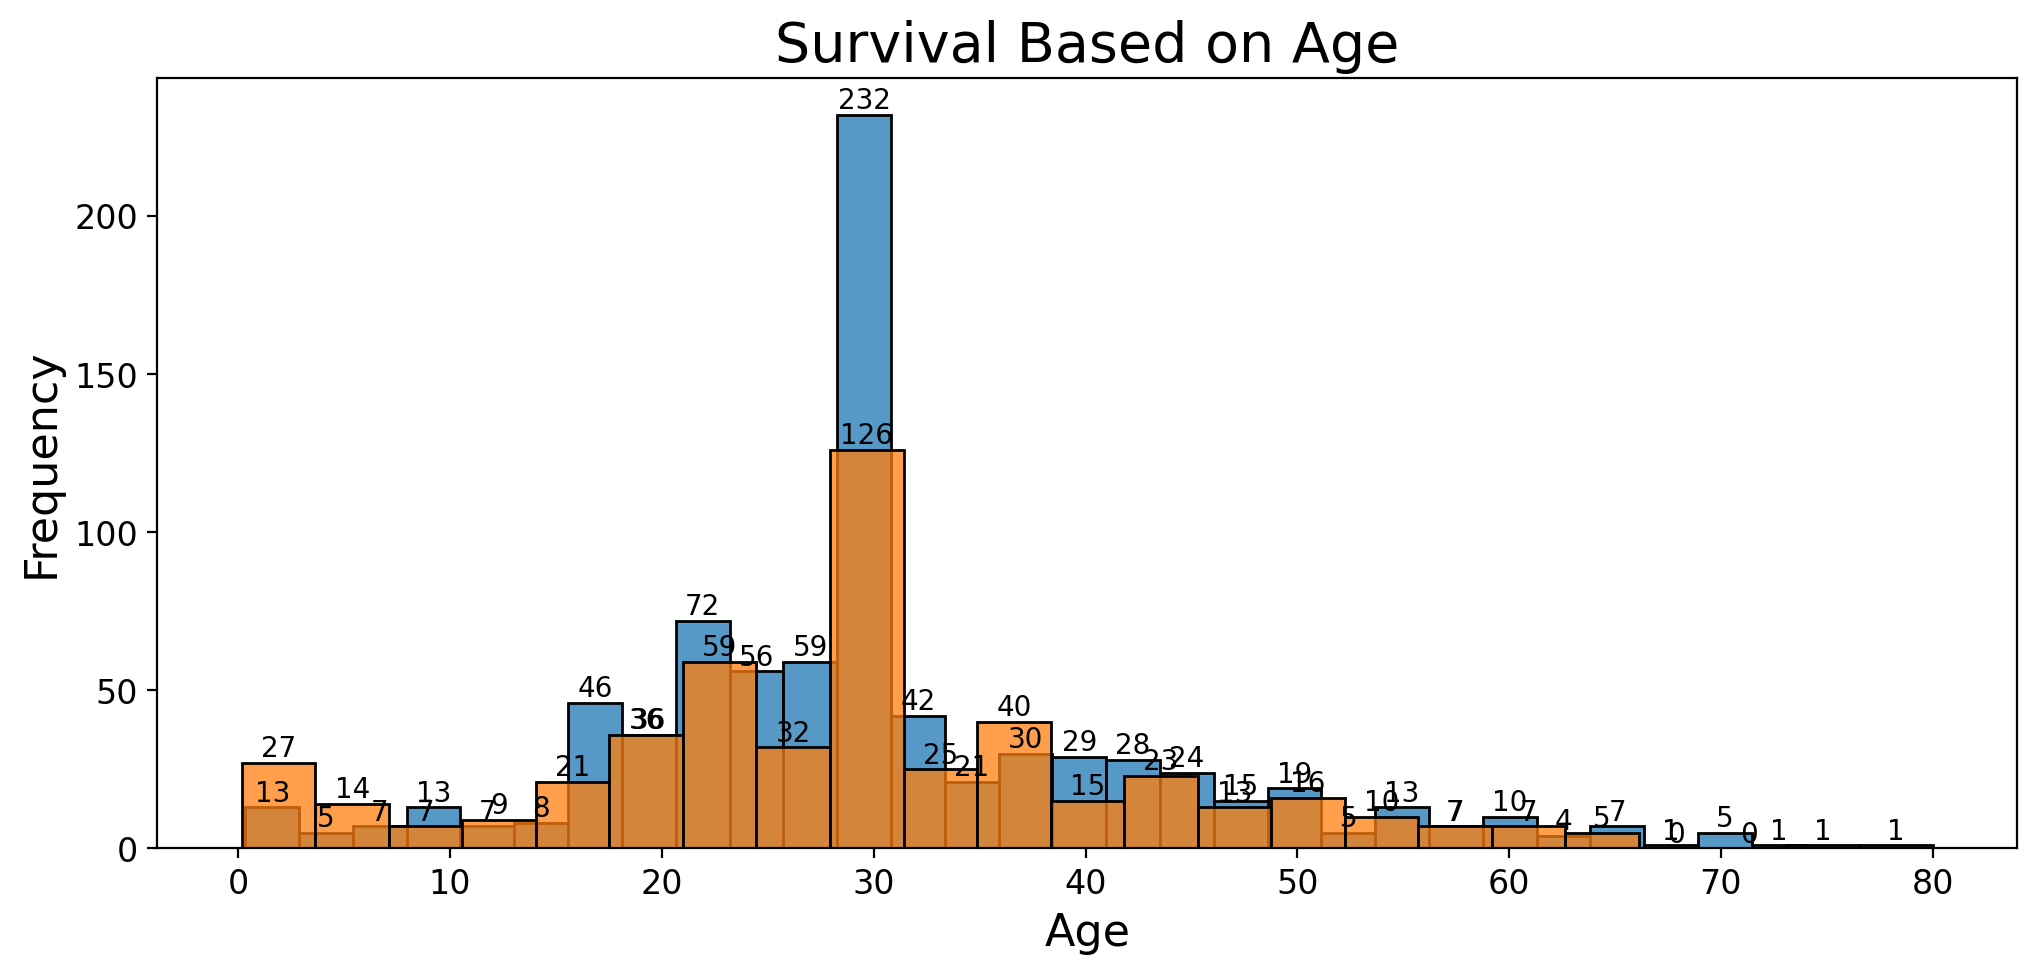

In [38]:
plt.figure(figsize = (12,5), dpi = 200)
ax = sns.histplot(df2[df2['Survived']==0]['Age'])
ax = sns.histplot(df2[df2['Survived']==1]['Age'])
for bars in ax.containers:
    ax.bar_label(bars)
    
ax.set_xlabel('Age', size = 16)    
ax.set_ylabel('Frequency', size = 16)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.title("Survival Based on Age", size = 20)    
plt.show()

<b> Approx 0-15 Age group, probability of died Passenger is considerably lower than Survival. And after 15 Age group, probability of died Passenger is considerably higher than Survival.

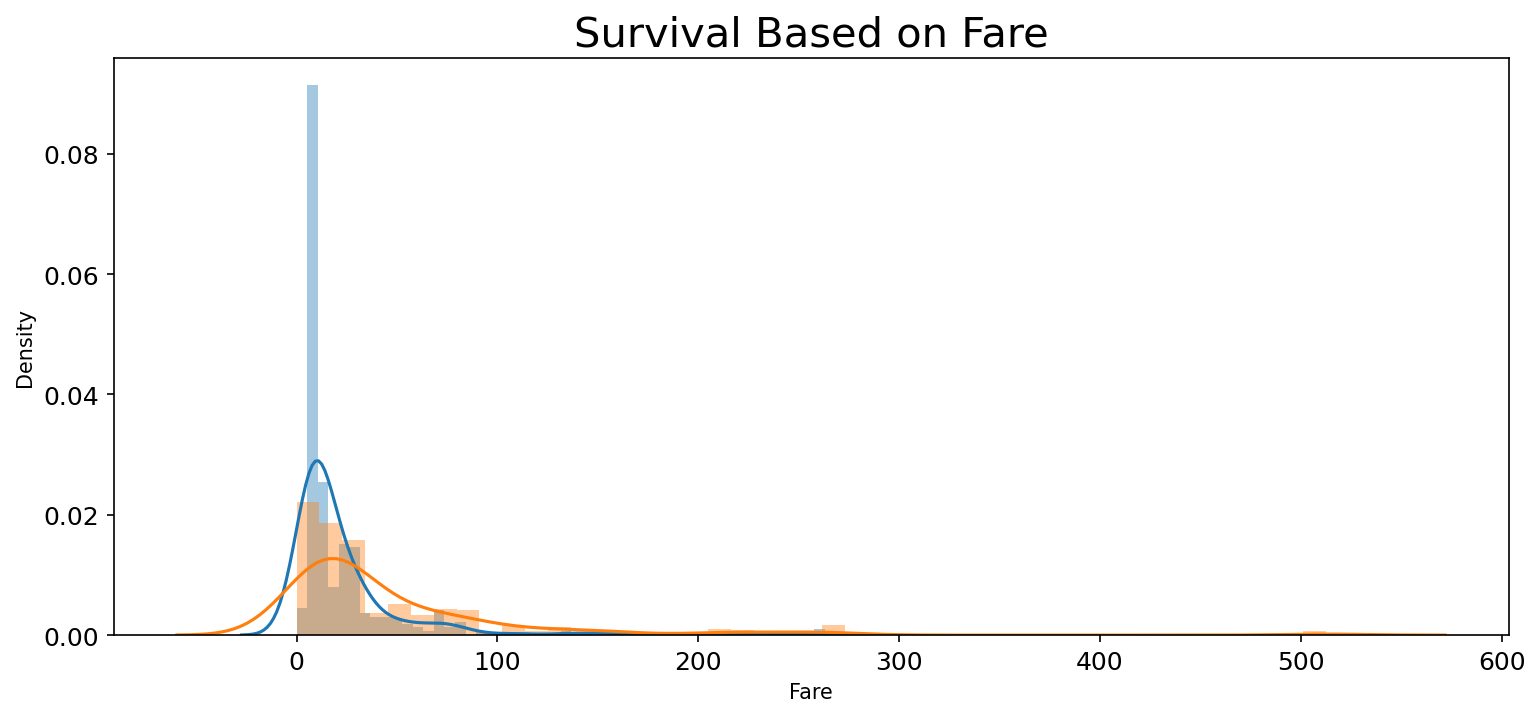

In [39]:
plt.figure(figsize = (12,5), dpi = 150)
sns.distplot(df2[df2['Survived']==0]['Fare'])
sns.distplot(df2[df2['Survived']==1]['Fare'])

ax.set_xlabel('Fare', size = 16)    
ax.set_ylabel('Density', size = 16)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.title("Survival Based on Fare", size = 20)  
plt.show()

<b> In lower Fare, Probability of passenger's Death is much higher than Survival. Once you cross that value where Fare has increased, After that, constantly, Probability of passenger's Death is lower than Survival.

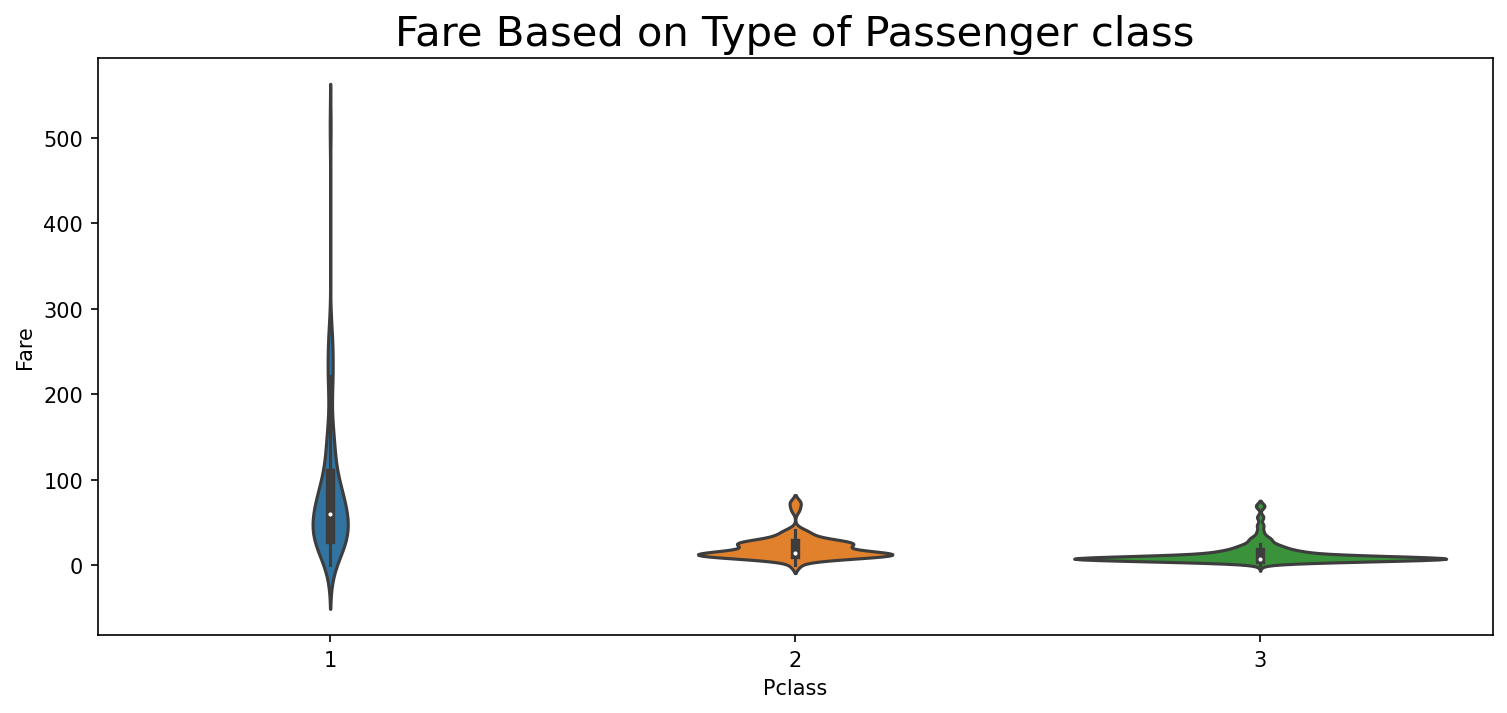

In [40]:
plt.figure(figsize = (12,5), dpi = 150)
ax = sns.violinplot(x = 'Pclass', y= 'Fare', data = df2)
for bars in ax.containers:
    ax.bar_label(bars)
plt.title("Fare Based on Type of Passenger class", size = 20)    
plt.show()

<b> Most of the Passenger travel in 3rd class of Pclass in Titanic beacause Fare is low.

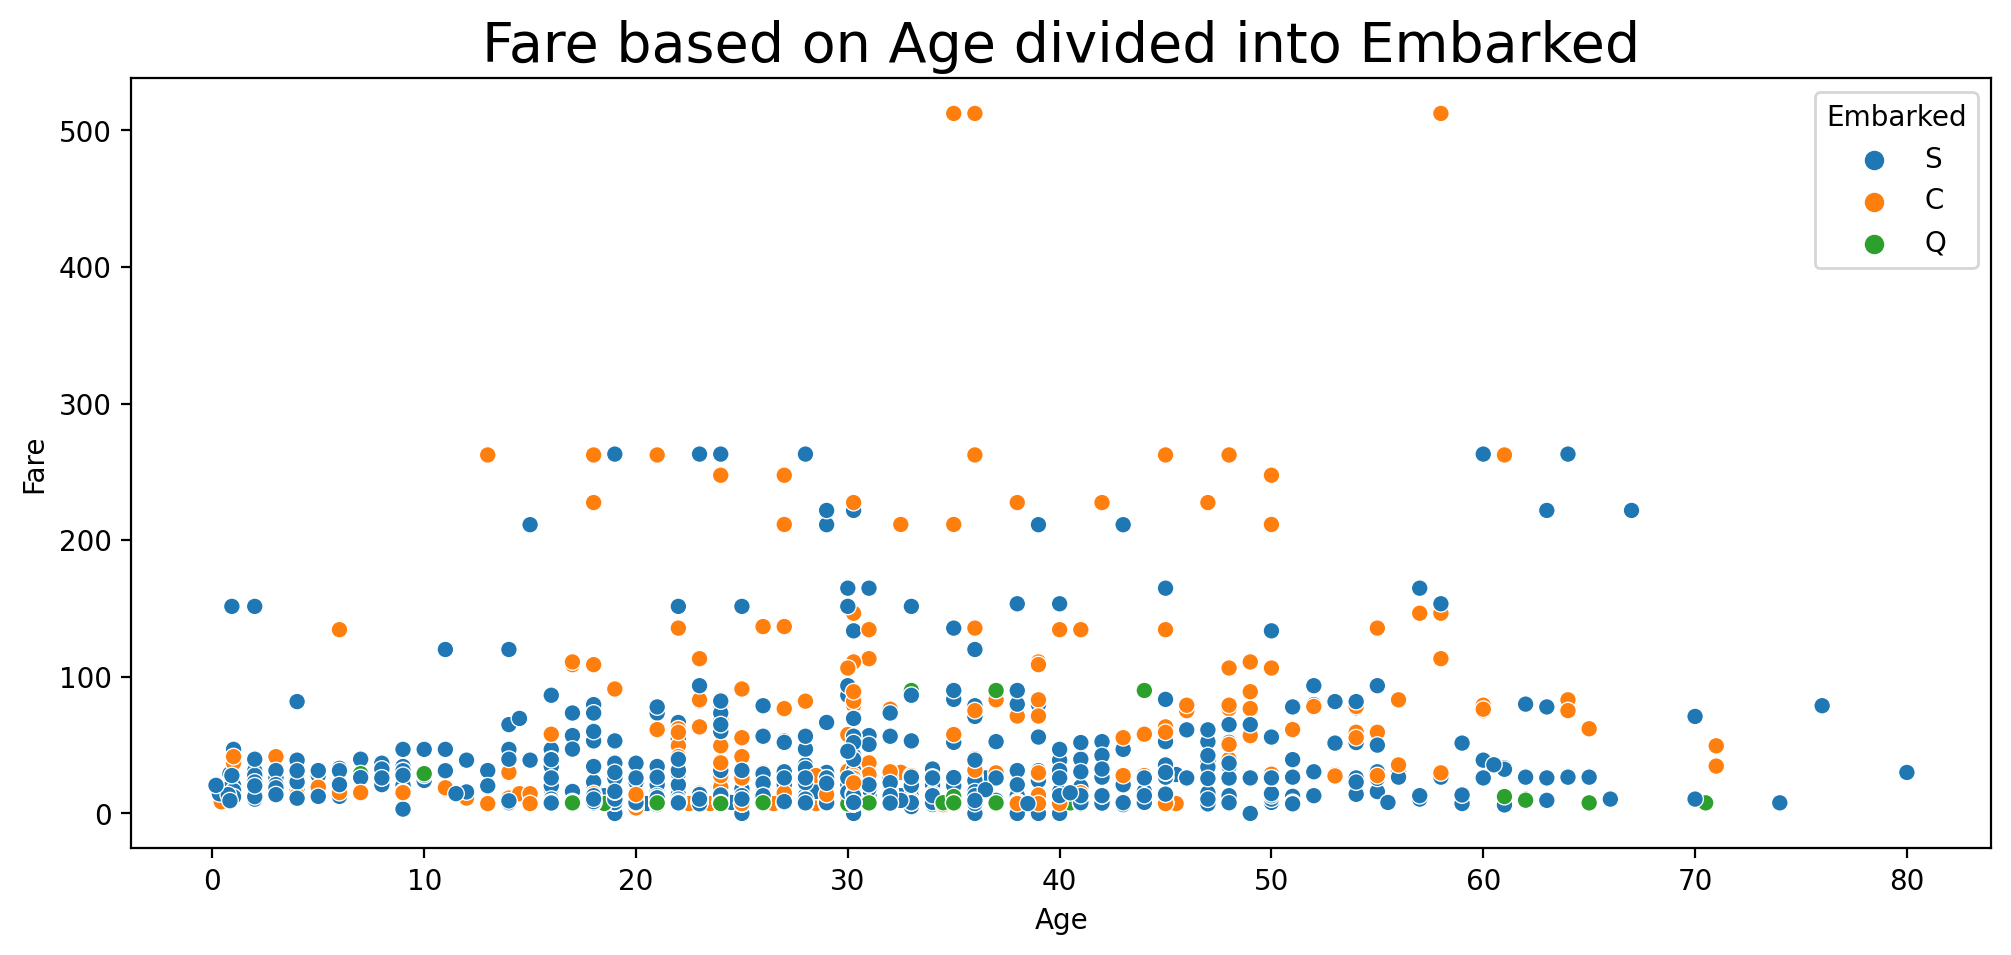

In [41]:
plt.figure(figsize = (12,5), dpi = 200)
sns.scatterplot(x = 'Age', y = 'Fare', hue = 'Embarked', data = df2)
plt.title("Fare based on Age divided into Embarked", size = 20)
plt.show()

<b> Most of 'C' city Passenger paid higher, between the 35-60 Age group

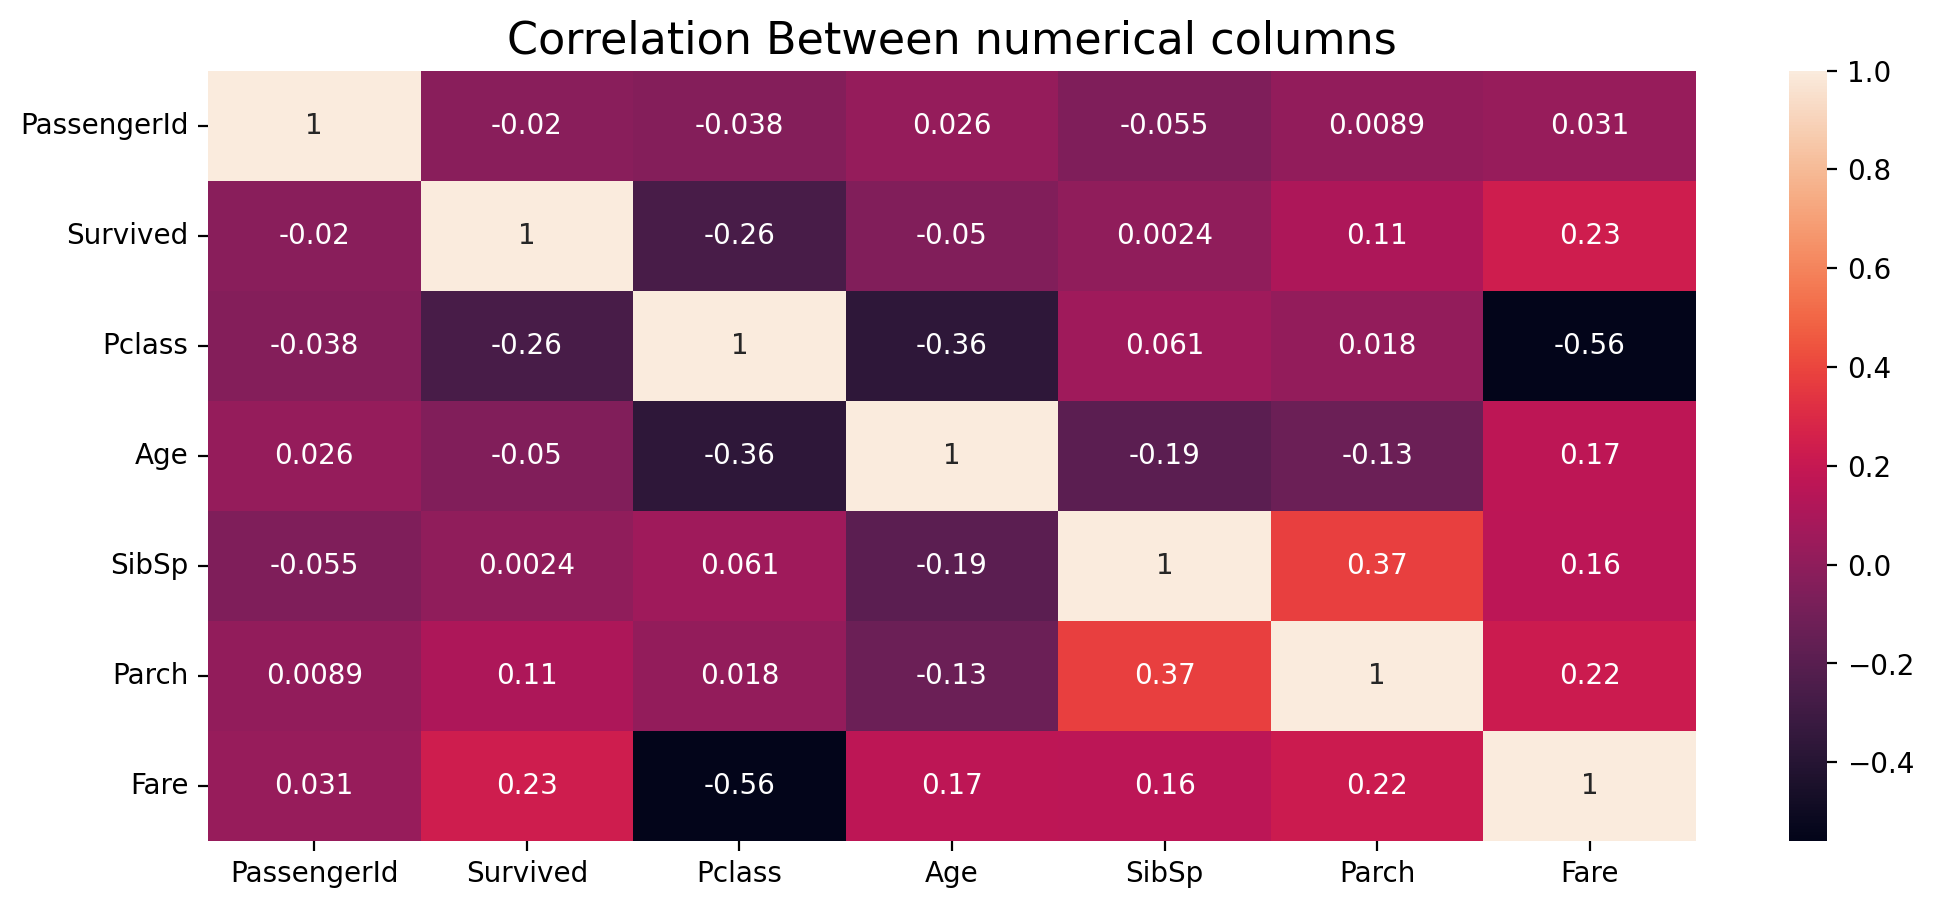

In [42]:
plt.figure(figsize = (12,5), dpi = 200)
sns.heatmap(df2.corr(), annot = True)
plt.title('Correlation Between numerical columns', size = 16)
plt.show()

<b> we can see that SibSp and Parch is highly correleated

### Conclusion

- 815 Passenger's died and 494 survived approx 37.7% Passenger are survived  in Titanic Disaster

- Number of Male is more than Female but Female are more Survived than Male which is 77.9%

- Most of Passengers alone travel in Titanic 

- Most of the Passenger's went on Titanic is 30 age group and most of 'C' city Passenger paid higher, between the 35-60 Age group

- Most of the Passenger travel in 3rd class of Pclass beacause ticket fare had cheaper but the highest number of the Passengers died in 3 class

- Approx 0-15 Age group, probability of died Passenger is considerably lower than Survival. And after 15 Age group, probability of died Passenger is considerably higher than Survival.

- In lower Fare, Probability of passenger's Death is much higher than Survival. Once you cross that value where Fare has increased, After that, constantly, Probability of passenger's Death is lower than Survival.